# 01 — Data preprocessing: official Pantheon+SH0ES supernova table

**Goal of this notebook:** turn the official `Pantheon+SH0ES.dat` file into a clean analysis table for a low-redshift Hubble-law measurement.

This notebook is intentionally more detailed than a minimal data loader because the preprocessing is part of the project. The main scientific idea is that Type Ia supernovae provide distance estimates, while their redshifts provide the expansion information. Before fitting any line, we must decide which rows and columns are suitable for the simplified model.

## Why this dataset?

For ordinary galaxies, the redshift is easy to get from spectra, but independent distances are difficult. Pantheon+SH0ES is more appropriate for the main Hubble-law analysis because it provides calibrated Type Ia supernova distance moduli and redshifts. This lets us build a distance-redshift diagram without inventing galaxy distances.

We are **not** redoing the original supernova light-curve calibration. Instead, we use the official published distance table as the input dataset and focus on the physics/data-analysis question: how does the Hubble-law fit behave after cleaning and sample selection?

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.pantheon import load_pantheon, clean_pantheon, save_cleaned
from src.cosmology import distance_modulus_to_mpc, redshift_to_velocity_lowz

## Step 1 — Load the official table

Expected input file:

```text
data/raw/Pantheon+SH0ES.dat
```

Run `python download_official_data.py` from the project root if it is missing. The file is whitespace-separated, so it can be read directly with `pandas.read_csv(..., delim_whitespace=True)`.

In [2]:
raw = load_pantheon(PROJECT_ROOT / "data/raw/Pantheon+SH0ES.dat")
print(raw.shape)
raw.head()

(1701, 47)


/mnt/4214D50D14D50537/LAPTOP/PhD_uni/classes/sem04/agent_based_modelling/DataDrivenAndAgentBasedModellingBMETEFTBsPAAMD-00/project2/src/pantheon.py:48: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, delim_whitespace=True, comment="#")


,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,0.1071,36,26.8859,0.864470,0.0991,1.4960,0.0381,0.005,1.0,0.003
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,0.0579,101,88.3064,0.812220,0.0971,1.4960,-0.0252,0.003,1.0,0.004
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,0.0278,165,233.5000,0.000358,0.0399,0.7134,0.0545,0.019,1.0,0.036
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,0.0667,55,100.1220,0.000193,0.0931,0.7134,0.0622,0.028,1.0,0.040
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,11.52270,0.880798,...,0.0522,146,109.8390,0.988740,0.0567,0.6110,0.0650,0.009,1.0,0.006


## Step 2 — Inspect relevant columns

The full table has many columns related to survey origin, light-curve fitting, calibration, host galaxy properties, and covariance information. For this educational Hubble-law analysis we keep only the columns needed to explain the measurement:

- `CID`: supernova identifier;
- `zHD`: redshift used for the Hubble diagram;
- `zCMB`, `zHEL`: redshift measured in other reference frames;
- `MU_SH0ES`: calibrated distance modulus;
- `MU_SH0ES_ERR_DIAG`: uncertainty on distance modulus;
- `IS_CALIBRATOR`: whether the object is a Cepheid calibrator;
- `USED_IN_SH0ES_HF`: whether the object belongs to the SH0ES Hubble-flow sample;
- `RA`, `DEC`: sky position;
- `VPEC`, `VPECERR`: peculiar-velocity correction information.

The project uses `zHD` because it is the column intended for the Hubble diagram, and `MU_SH0ES` because it is the distance estimate in the SH0ES-calibrated table.

In [3]:
interesting_cols = [c for c in [
    "CID", "IDSURVEY", "zHD", "zHDERR", "zCMB", "zCMBERR", "zHEL", "zHELERR",
    "MU_SH0ES", "MU_SH0ES_ERR_DIAG", "CEPH_DIST", "IS_CALIBRATOR", "USED_IN_SH0ES_HF",
    "RA", "DEC", "VPEC", "VPECERR", "HOST_LOGMASS"
] if c in raw.columns]
raw[interesting_cols].head()

,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,MU_SH0ES,MU_SH0ES_ERR_DIAG,CEPH_DIST,IS_CALIBRATOR,USED_IN_SH0ES_HF,RA,DEC,VPEC,VPECERR,HOST_LOGMASS
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,28.9987,1.516450,29.1770,1,0,210.774,54.2737,0.0,250,10.67700
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,29.0559,1.517470,29.1770,1,0,210.774,54.2737,0.0,250,10.67700
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,30.7233,0.782372,30.8433,1,0,186.803,9.4203,0.0,250,9.63300
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,30.7449,0.799068,30.8433,1,0,186.803,9.4203,0.0,250,9.63300
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,30.7757,0.881212,-9.0000,0,0,188.510,7.7016,0.0,250,8.46247


## Step 3 — Cleaning decisions

The cleaning function applies decisions that are simple enough to justify in a class report:

1. **Convert numeric-looking columns to numeric values.** This avoids accidental string columns.
2. **Replace placeholder missing values** such as `-9`, `-99`, and `-999` with `NaN`.
3. **Drop rows missing the essential quantities**: redshift, distance modulus, or distance-modulus uncertainty.
4. **Exclude calibrator objects by default.** Calibrators are useful for anchoring the distance scale, but for a simple Hubble-flow fit we avoid mixing local calibrator objects with the Hubble-flow sample.
5. **Keep only low-redshift objects**, by default `0.01 <= zHD <= 0.15`. The lower cut reduces objects whose peculiar velocities are comparable to the Hubble-flow velocity; the upper cut keeps the analysis in a range where the simple linear approximation is still understandable.

This cleaning is not the only possible choice. Notebook 03 investigates how changing redshift selection changes the result.

In [4]:
clean, summary = clean_pantheon(raw, z_min=0.01, z_max=0.15, exclude_calibrators=True)
summary.to_frame()

,raw_rows,rows_after_missing,rows_after_calibrator_filter,rows_after_redshift_cut,z_min,z_max,mu_min,mu_max
0,1701,1701,1624,705,0.01016,0.1494,32.7794,39.5154


## Step 4 — Derived physical quantities

The table gives distance modulus, not distance directly. We convert using

$$
D_L(\mathrm{Mpc}) = 10^{(\mu - 25)/5}.
$$

For a low-redshift educational Hubble fit, redshift is converted to an approximate velocity using

$$
v \approx cz.
$$

A small but important detail: Pantheon+ reports **luminosity distance**. For the local linear relation, the notebooks now also store

$$
d_{Hubble} \approx D_L/(1+z),
$$

which removes the leading luminosity-distance redshift factor. Notebook 02 compares both choices instead of hiding this assumption.


In [5]:
clean[[
    "CID", "zHD", "MU_SH0ES", "MU_SH0ES_ERR_DIAG",
    "distance_mpc", "hubble_distance_mpc",
    "distance_err_mpc", "hubble_distance_err_mpc",
    "velocity_km_s",
]].head()


,CID,zHD,MU_SH0ES,MU_SH0ES_ERR_DIAG,distance_mpc,hubble_distance_mpc,distance_err_mpc,hubble_distance_err_mpc,velocity_km_s
0,2013E,0.01016,32.7794,0.348547,35.964995,35.603265,5.772807,5.714745,3045.891373
1,1999ac,0.01017,32.9182,0.365223,38.338931,37.952950,6.448279,6.383360,3048.889298
2,1999ac,0.01017,32.9674,0.341878,39.217509,38.822682,6.174430,6.112268,3048.889298
3,2009an,0.01026,33.3378,0.306294,46.511463,46.039102,6.560609,6.493981,3075.870619
4,2009an,0.01026,33.2253,0.299086,44.163146,43.714634,6.082775,6.021000,3075.870619


In [6]:
clean.describe()[["zHD", "MU_SH0ES", "distance_mpc", "velocity_km_s"]]

,zHD,MU_SH0ES,distance_mpc,velocity_km_s
count,705.000000,705.000000,705.000000,705.000000
mean,0.044250,35.824502,192.710308,13265.714209
std,0.035694,1.531274,164.972828,10700.758663
min,0.010160,32.779400,35.964995,3045.891373
25%,0.021340,34.756100,89.375812,6397.571054
50%,0.030360,35.530400,127.667396,9101.699025
75%,0.050490,36.640200,212.833506,15136.521204
max,0.149400,39.515400,799.981603,44788.993225


## Step 4b — Statistical overview plots

Before saving the cleaned table, it is useful to look at standard statistical views of the key quantities. These plots check the cleaned sample distribution, uncertainty scale, correlations, survey composition, and the main distance-redshift relationship.

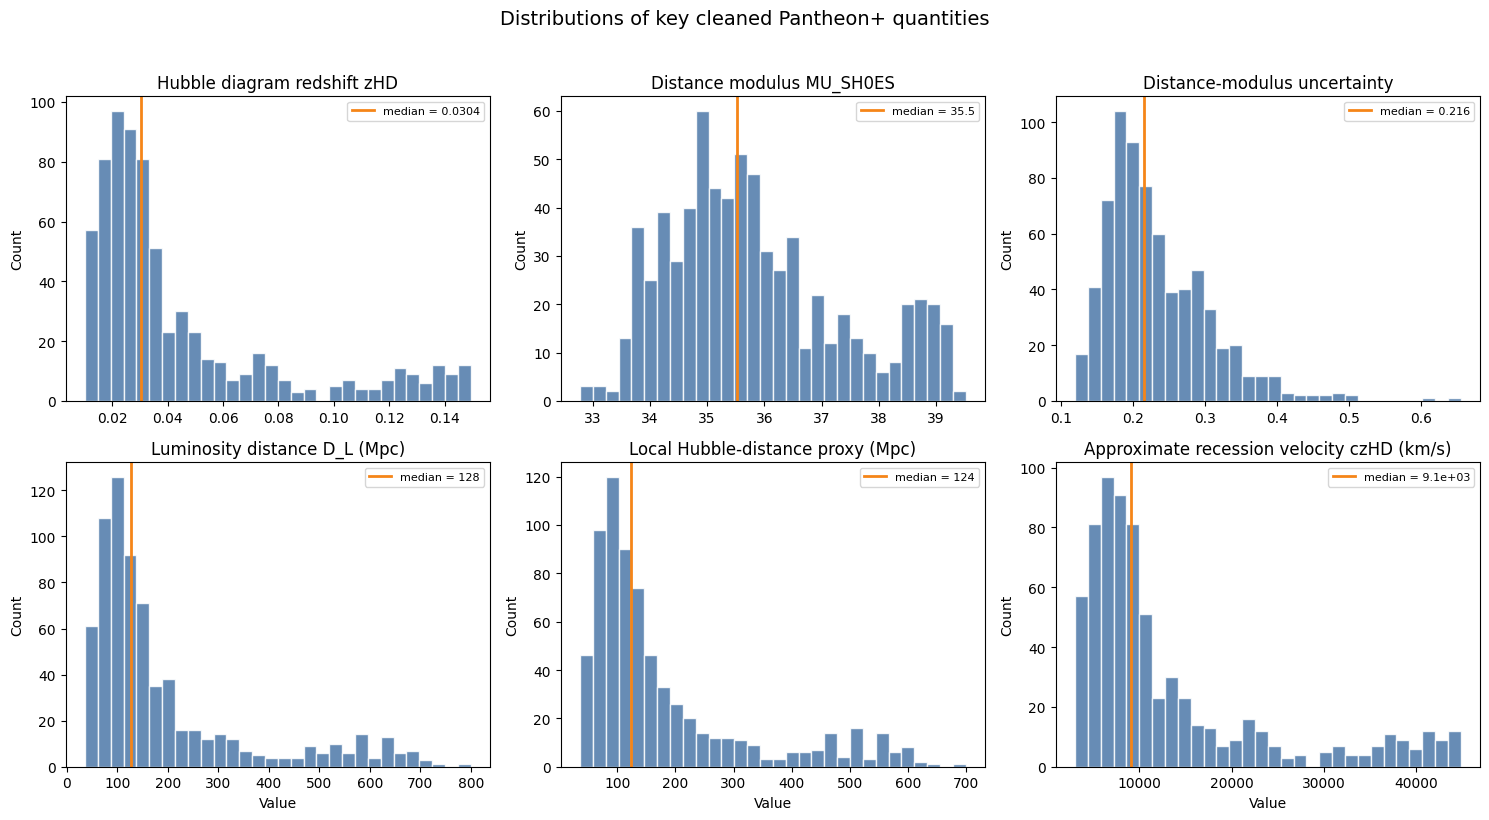

In [7]:
fig_dir = PROJECT_ROOT / "figures"
fig_dir.mkdir(exist_ok=True)

plot_specs = [
    ("zHD", "Hubble diagram redshift zHD"),
    ("MU_SH0ES", "Distance modulus MU_SH0ES"),
    ("MU_SH0ES_ERR_DIAG", "Distance-modulus uncertainty"),
    ("distance_mpc", "Luminosity distance D_L (Mpc)"),
    ("hubble_distance_mpc", "Local Hubble-distance proxy (Mpc)"),
    ("velocity_km_s", "Approximate recession velocity czHD (km/s)"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, label) in zip(axes.ravel(), plot_specs):
    values = clean[col].dropna()
    median = values.median()
    ax.hist(values, bins=30, color="#4C78A8", edgecolor="white", alpha=0.85)
    ax.axvline(median, color="#F58518", linewidth=2, label=f"median = {median:.3g}")
    ax.set_title(label)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel("Value")

fig.suptitle("Distributions of key cleaned Pantheon+ quantities", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(fig_dir / "pantheon_preprocessing_distributions.png", dpi=180, bbox_inches="tight")

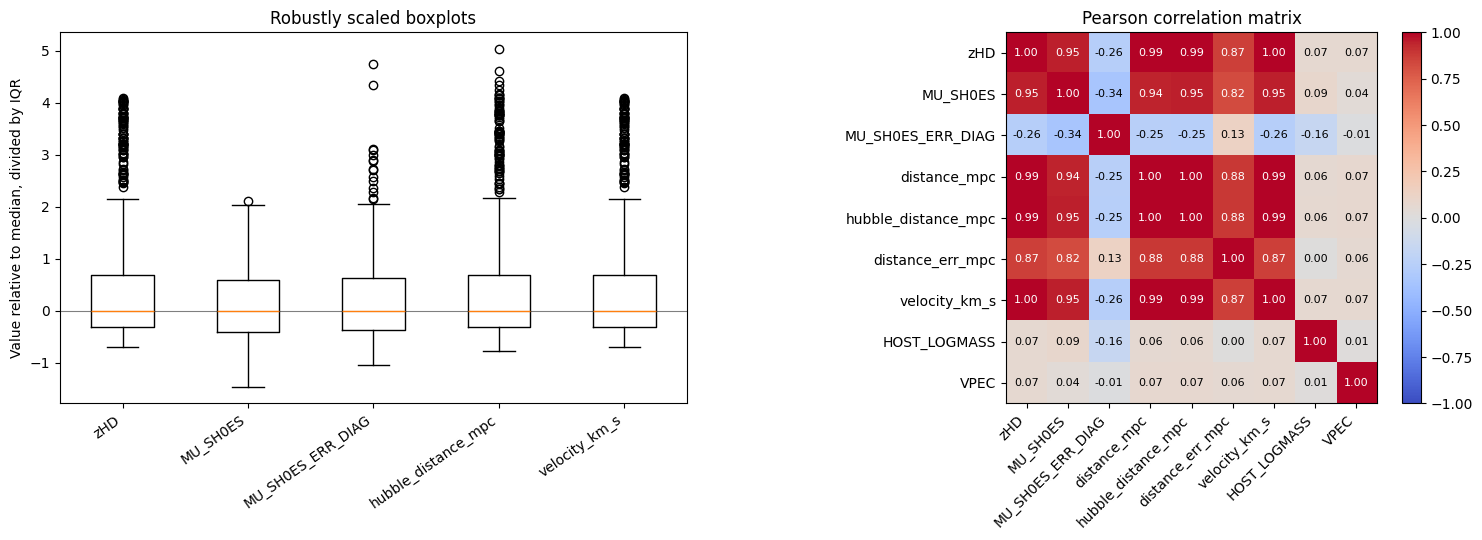

In [8]:
box_cols = ["zHD", "MU_SH0ES", "MU_SH0ES_ERR_DIAG", "hubble_distance_mpc", "velocity_km_s"]
box_data = clean[box_cols].copy()
iqr = box_data.quantile(0.75) - box_data.quantile(0.25)
box_scaled = (box_data - box_data.median()) / iqr.replace(0, np.nan)
box_scaled = box_scaled.replace([np.inf, -np.inf], np.nan)

corr_cols = [
    "zHD", "MU_SH0ES", "MU_SH0ES_ERR_DIAG", "distance_mpc",
    "hubble_distance_mpc", "distance_err_mpc", "velocity_km_s",
    "HOST_LOGMASS", "VPEC",
]
corr_cols = [c for c in corr_cols if c in clean.columns]
corr = clean[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].boxplot([box_scaled[c].dropna() for c in box_cols], showfliers=True)
axes[0].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[0].set_title("Robustly scaled boxplots")
axes[0].set_ylabel("Value relative to median, divided by IQR")
axes[0].set_xticks(range(1, len(box_cols) + 1))
axes[0].set_xticklabels(box_cols, rotation=35, ha="right")

im = axes[1].imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set_title("Pearson correlation matrix")
axes[1].set_xticks(range(len(corr_cols)), labels=corr_cols, rotation=45, ha="right")
axes[1].set_yticks(range(len(corr_cols)), labels=corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        value = corr.iloc[i, j]
        text_color = "white" if abs(value) > 0.55 else "black"
        axes[1].text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(fig_dir / "pantheon_preprocessing_boxplots_correlations.png", dpi=180, bbox_inches="tight")

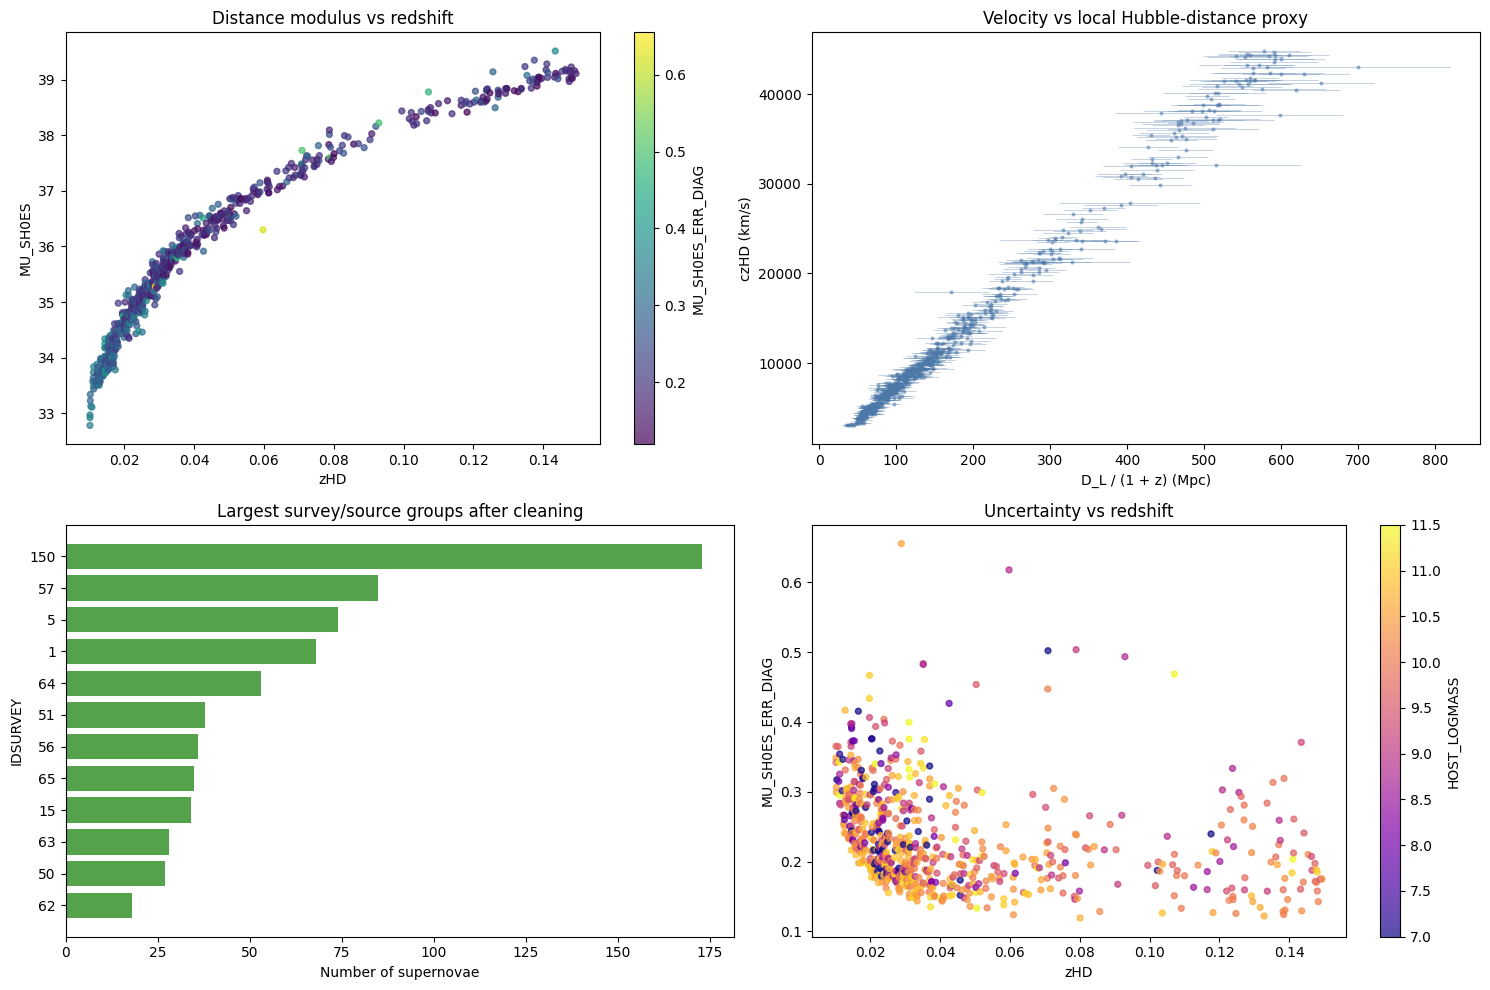

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sc = axes[0, 0].scatter(
    clean["zHD"], clean["MU_SH0ES"],
    c=clean["MU_SH0ES_ERR_DIAG"], s=18, alpha=0.7, cmap="viridis",
)
axes[0, 0].set_title("Distance modulus vs redshift")
axes[0, 0].set_xlabel("zHD")
axes[0, 0].set_ylabel("MU_SH0ES")
fig.colorbar(sc, ax=axes[0, 0], label="MU_SH0ES_ERR_DIAG")

axes[0, 1].errorbar(
    clean["hubble_distance_mpc"], clean["velocity_km_s"],
    xerr=clean["hubble_distance_err_mpc"], fmt=".", markersize=4,
    linewidth=0.5, alpha=0.45, color="#4C78A8",
)
axes[0, 1].set_title("Velocity vs local Hubble-distance proxy")
axes[0, 1].set_xlabel("D_L / (1 + z) (Mpc)")
axes[0, 1].set_ylabel("czHD (km/s)")

survey_counts = clean["IDSURVEY"].value_counts().head(12).sort_values()
axes[1, 0].barh(survey_counts.index.astype(str), survey_counts.values, color="#54A24B")
axes[1, 0].set_title("Largest survey/source groups after cleaning")
axes[1, 0].set_xlabel("Number of supernovae")
axes[1, 0].set_ylabel("IDSURVEY")

if "HOST_LOGMASS" in clean.columns and clean["HOST_LOGMASS"].notna().any():
    hm = axes[1, 1].scatter(
        clean["zHD"], clean["MU_SH0ES_ERR_DIAG"],
        c=clean["HOST_LOGMASS"], s=18, alpha=0.7, cmap="plasma",
    )
    fig.colorbar(hm, ax=axes[1, 1], label="HOST_LOGMASS")
else:
    axes[1, 1].scatter(clean["zHD"], clean["MU_SH0ES_ERR_DIAG"], s=18, alpha=0.7, color="#B279A2")
axes[1, 1].set_title("Uncertainty vs redshift")
axes[1, 1].set_xlabel("zHD")
axes[1, 1].set_ylabel("MU_SH0ES_ERR_DIAG")

fig.tight_layout()
fig.savefig(fig_dir / "pantheon_preprocessing_relationships.png", dpi=180, bbox_inches="tight")

## Step 5 — Save processed data

The cleaned table is saved so the later notebooks do not silently redo preprocessing with different assumptions.

In [10]:
out = PROJECT_ROOT / "data/processed/pantheon_clean.csv"
save_cleaned(clean, out)
summary.to_frame().to_csv(PROJECT_ROOT / "report/pantheon_cleaning_summary.csv", index=False)
print(f"Saved {len(clean)} cleaned objects to {out}")

Saved 705 cleaned objects to /mnt/4214D50D14D50537/LAPTOP/PhD_uni/classes/sem04/agent_based_modelling/DataDrivenAndAgentBasedModellingBMETEFTBsPAAMD-00/project2/data/processed/pantheon_clean.csv


## Preprocessing conclusion

After cleaning, the project has a low-redshift Pantheon+SH0ES sample with redshift, distance modulus, uncertainty, luminosity distance, a local Hubble-distance proxy, and approximate recession velocity.

The saved table deliberately keeps both `distance_mpc` and `hubble_distance_mpc`. This makes the next notebooks more transparent: they can show how much the fitted slope changes if we use the raw luminosity distance versus the corrected local-distance proxy.
